# Image Compression - Assignment P11

#### ONLY MODIFY CELLS THAT SPECIFICALLY PROMPT YOU TO ENTER CODE OR TEXT.

Please always fill out the following data for the students in your submission team to make our life a bit easier:

#### Name(s): PLEASE FILL OUT
#### Student ID(s): PLEASE FILL OUT

In [1]:
# Please do not modify the imports.
import numpy as np
import math
import matplotlib.pyplot as plt # for displaying images
from pathlib import Path # handling paths in your file system (OS agnostic)
from PIL import Image # for loading images
from tqdm import tqdm

# A little function to enable some messages for debugging.
def print_verbose(verbose, *args, **kwargs):
    if verbose:
        print(*args, **kwargs)

## P11 Data Optimisation for Homogeneous Diffusion Inpainting (24= 4+8+12P)
In this assignment, you will implement a simple version of homogeneous diffusion inpainting and multiple ways to generate masks. 

### Preliminaries
The following cell loads and displays the test image.

Tabby test image courtesy of __[torne (where's my lens cap?)]("https://commons.wikimedia.org/wiki/File:Red_tabby_cat_in_field,_Japan_(cropped).jpg")__ __[CC BY 2.0](https://creativecommons.org/licenses/by/2.0/deed.en)__ (subsampled).


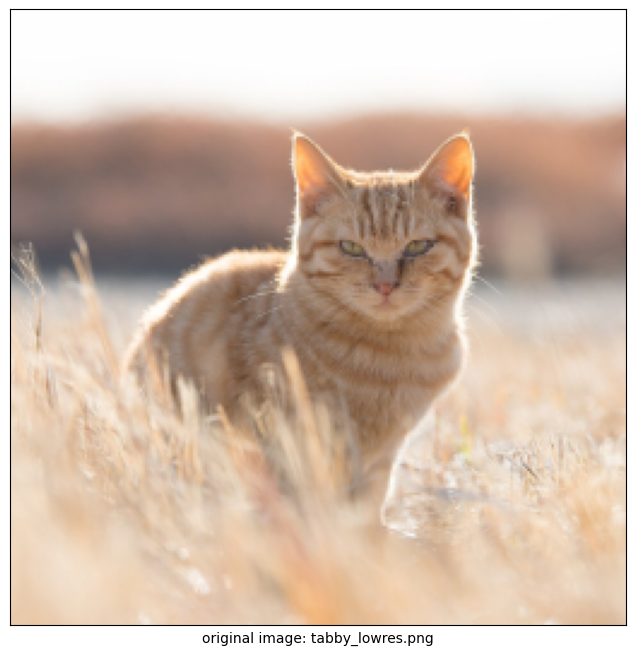

In [2]:
image_path = Path("tabby_lowres.png")
original_image = np.array(Image.open(image_path))
original_caption = "original image: tabby_lowres.png"

def display_images(image_list, rows=1, figsize=(8,8)):
    # determine how many columns are needed to sort the images into the desired number of rows
    columns = math.ceil(max(len(image_list) / rows, 1))

    plt.figure(figsize=figsize)

    current_image = 1
    for image, caption in image_list:
        plt.subplot(rows, columns, current_image)
        #print(image.shape) 
        if (len(image.shape) == 3 and image.shape[2] == 1):
            # Binary images need to be in a 2-D array shape for imshow. Thus, we remove the channel dimension.
            plt.imshow(np.squeeze(image, axis=2), cmap=plt.cm.gray)
        elif (len(image.shape) == 2):
            # Plot single channel image as grayscale.
            plt.imshow(image, cmap=plt.cm.gray)
        elif (len(image.shape) == 3 and image.shape[2] == 3):
            # RGB images can be plotted directly.
            plt.imshow(image)
        else: 
            print("Wrong image format, cannot be displayed.")
        plt.grid(False)
        plt.xticks([])
        plt.yticks([])
        plt.xlabel(caption)
        current_image += 1
    plt.show()

# with figsize you can rescale the size of the displayed output
display_images([(original_image, original_caption)])


### P11.1 Creating Random and Regular Masks (4=2+2P)

In the cells below, fill in the missing code for the following routines:
- <code>create_random_mask</code> (1P): Given a target density, select .
- <code>chroma_subsampling</code> (2P):  Subdivide image into blocks and reduce the pixel values of each block to a single pixel with averaging.

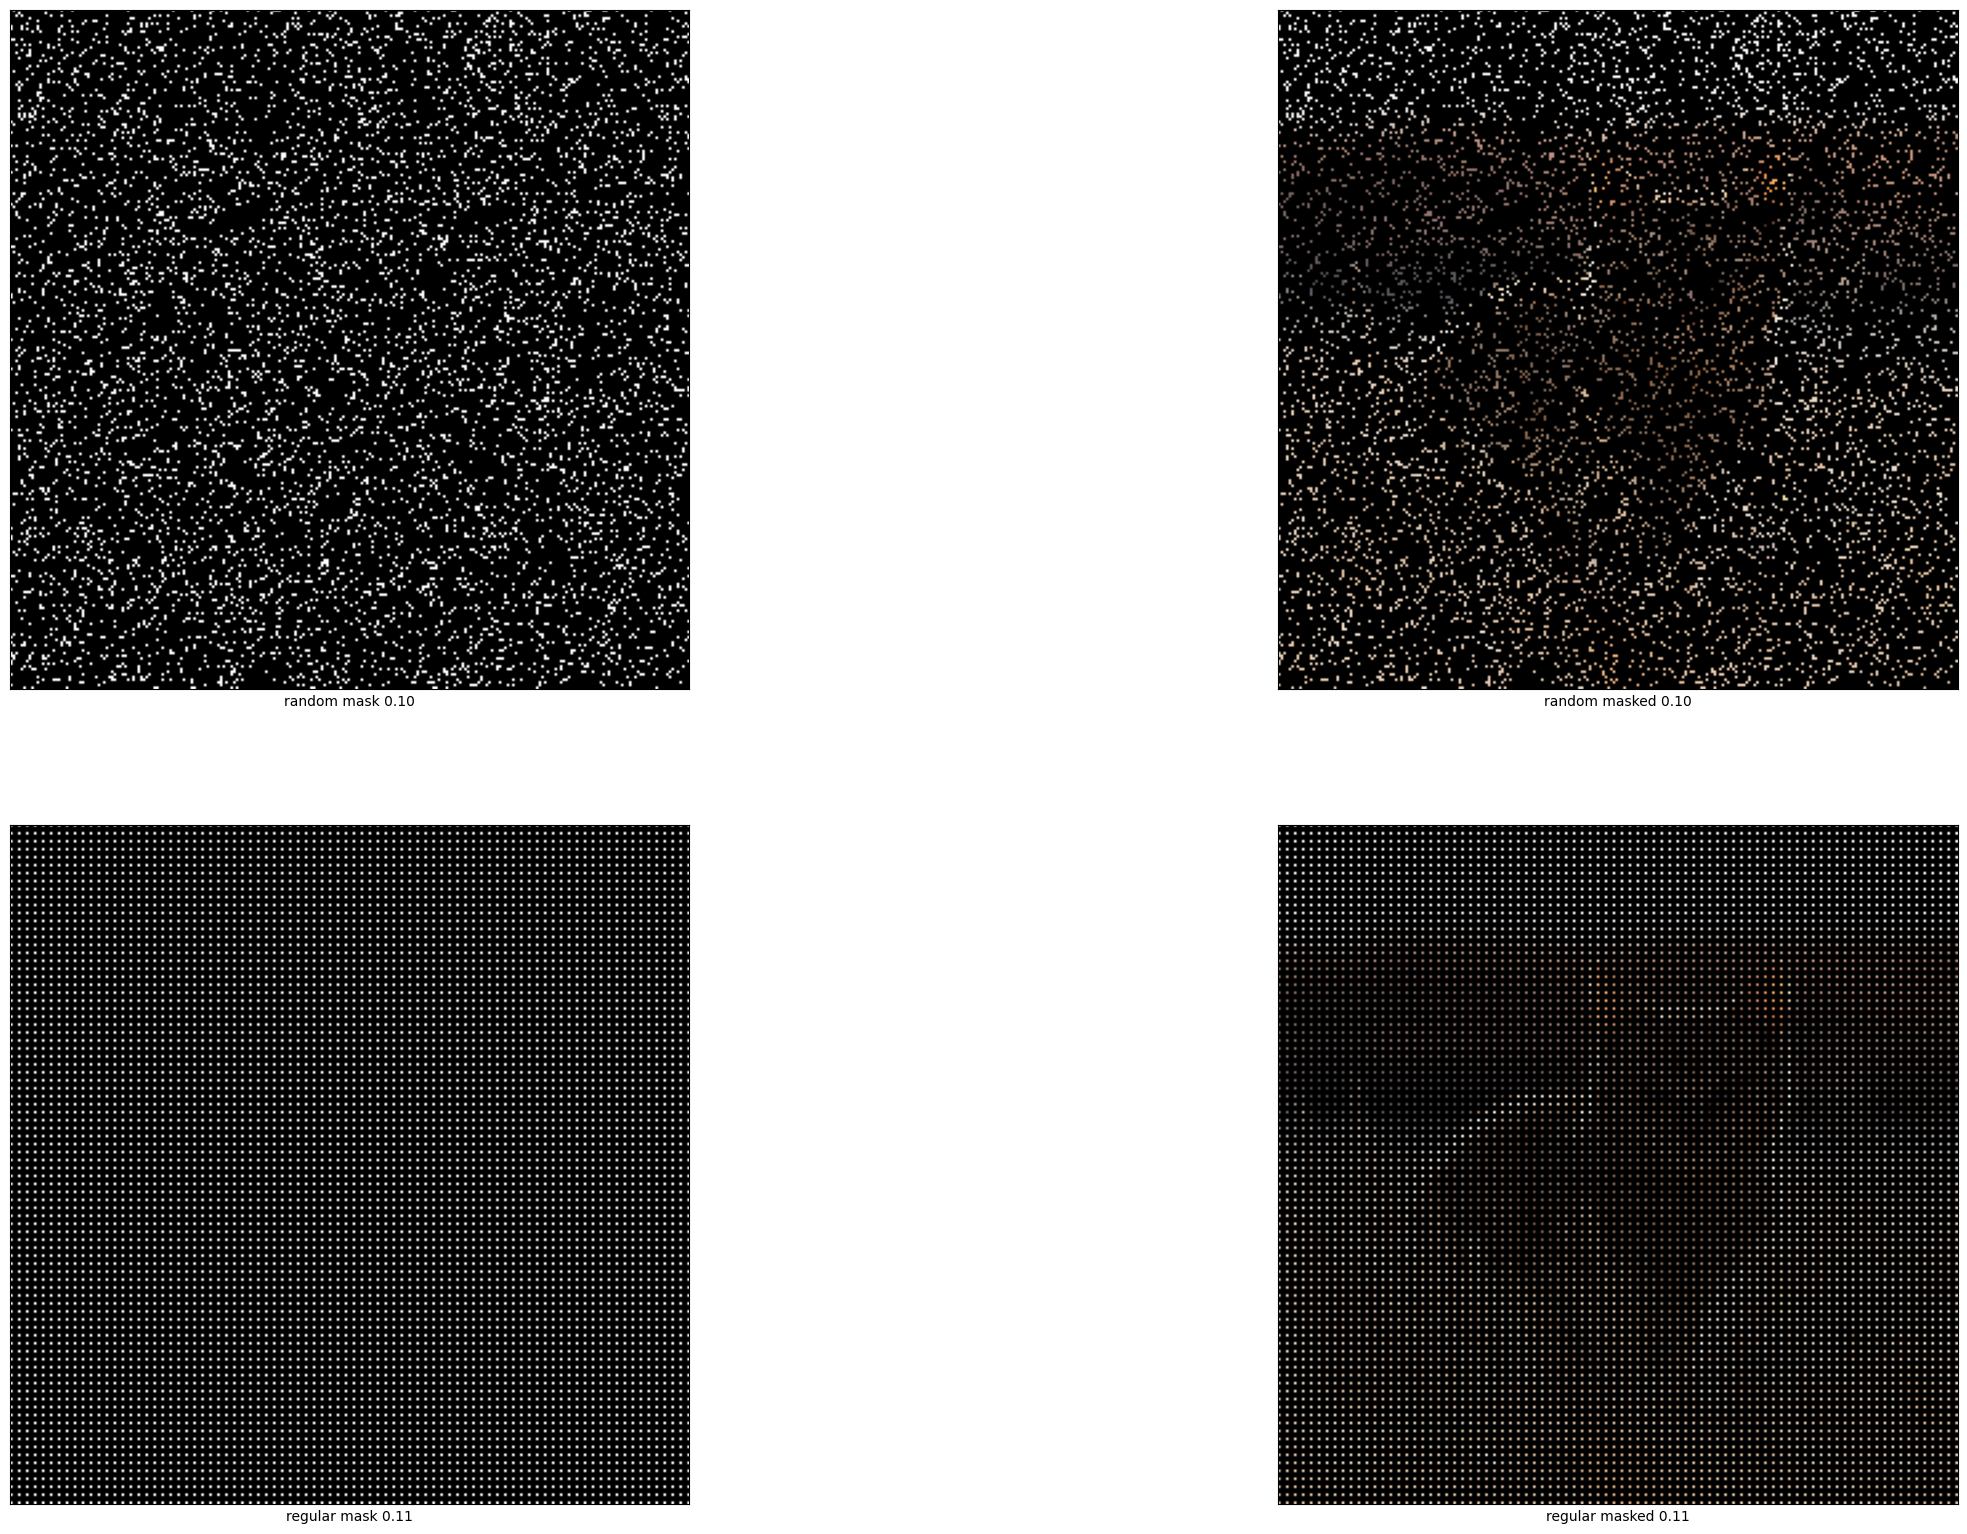

In [3]:
def create_random_mask(shape, density):
    nx, ny = shape
    total_pixels = nx * ny
    known = max(1, min(total_pixels, round(total_pixels * density)))
    # ADD YOUR OWN CODE HERE.
    mask = np.zeros(total_pixels, dtype=bool)
    mask[:known] = True
    np.random.shuffle(mask)
    return mask.reshape(shape)

def create_regular_mask(shape, density):
    nx, ny = shape
    total_pixels = nx * ny
    target_known = int(total_pixels * density)
    # ADD YOUR OWN CODE HERE.
    k = max(1, int(np.sqrt(total_pixels / target_known)))
    mask = np.zeros((nx, ny), dtype=bool)
    mask[::k, ::k] = True
    return mask

def get_density(mask):
    num_known = np.sum(mask)
    total = mask.size
    return num_known / total

# Create masks and visualise them.
shape = original_image.shape[:2]
density = 0.1
random_mask = create_random_mask(shape, density)
regular_mask = create_regular_mask(shape, density)
random_masked = original_image.copy()
random_masked[~random_mask] = 0
regular_masked = original_image.copy()
regular_masked[~regular_mask] = 0
random_density = get_density(random_mask)
regular_density = get_density(regular_mask)
display_images([(random_mask, f'random mask {random_density:.2f}' ),
                (random_masked, f'random masked {random_density:.2f}' ),
                (regular_mask, f"regular mask {regular_density:.2f}"),
                (regular_masked, f"regular masked {regular_density:.2f}")], rows=3, figsize=(30,30))

### P11.2 Homogeneous Diffusion Inpainting. (6P+2P)
For our data optimisation task, we need a reconstruction method. Here, we will use a naive implementation of homogeneous diffusion - the explicit scheme from the lecture. This is not the most efficient way to implement it, but quite straightforward.

Complete the method <code>inpaint_hom_diff</code> in the next cell. Note that we only have a loop for the colour channels. Note that while you can directly implement the for loop over the pixel coordinates i,j and the colour channels as implied in the lecture, but this is not the most elegant solution in Python.

Once you have implemented homogeneous diffusion inpainting, experiment with the number of iterations. What are your findings? Which number of iterations do you propose? What influence might a fixed number of iterations have on sparsification or NLPE?

**Write your answer here.**

The random mask requires more iterations than the regular one since there are larger gaps between pixels. In each iteration, information can only spread to direct neighbours and thus even at similar density, the distribution of mask points matters a lot for convergence. A reasonable choice for the parameter is between 100 and 200 iterations. After that you have diminishing returns in the reconstruction quality. (Note that this does not necessarily mean that the inpainting has really converged, but the impact on the error and visual quality is minimal.)

Unfortunately, this also means that the distribution of points in a sparsification or NLPE data optimisation will be biased by a fixed number of iterations. It limits the maximum distance that data points can have from each other without leading to holes in the reconstruction. We still use a fixed number of iterations here, but in practice you should make sure that your inpainting converges for any configuration of known data.

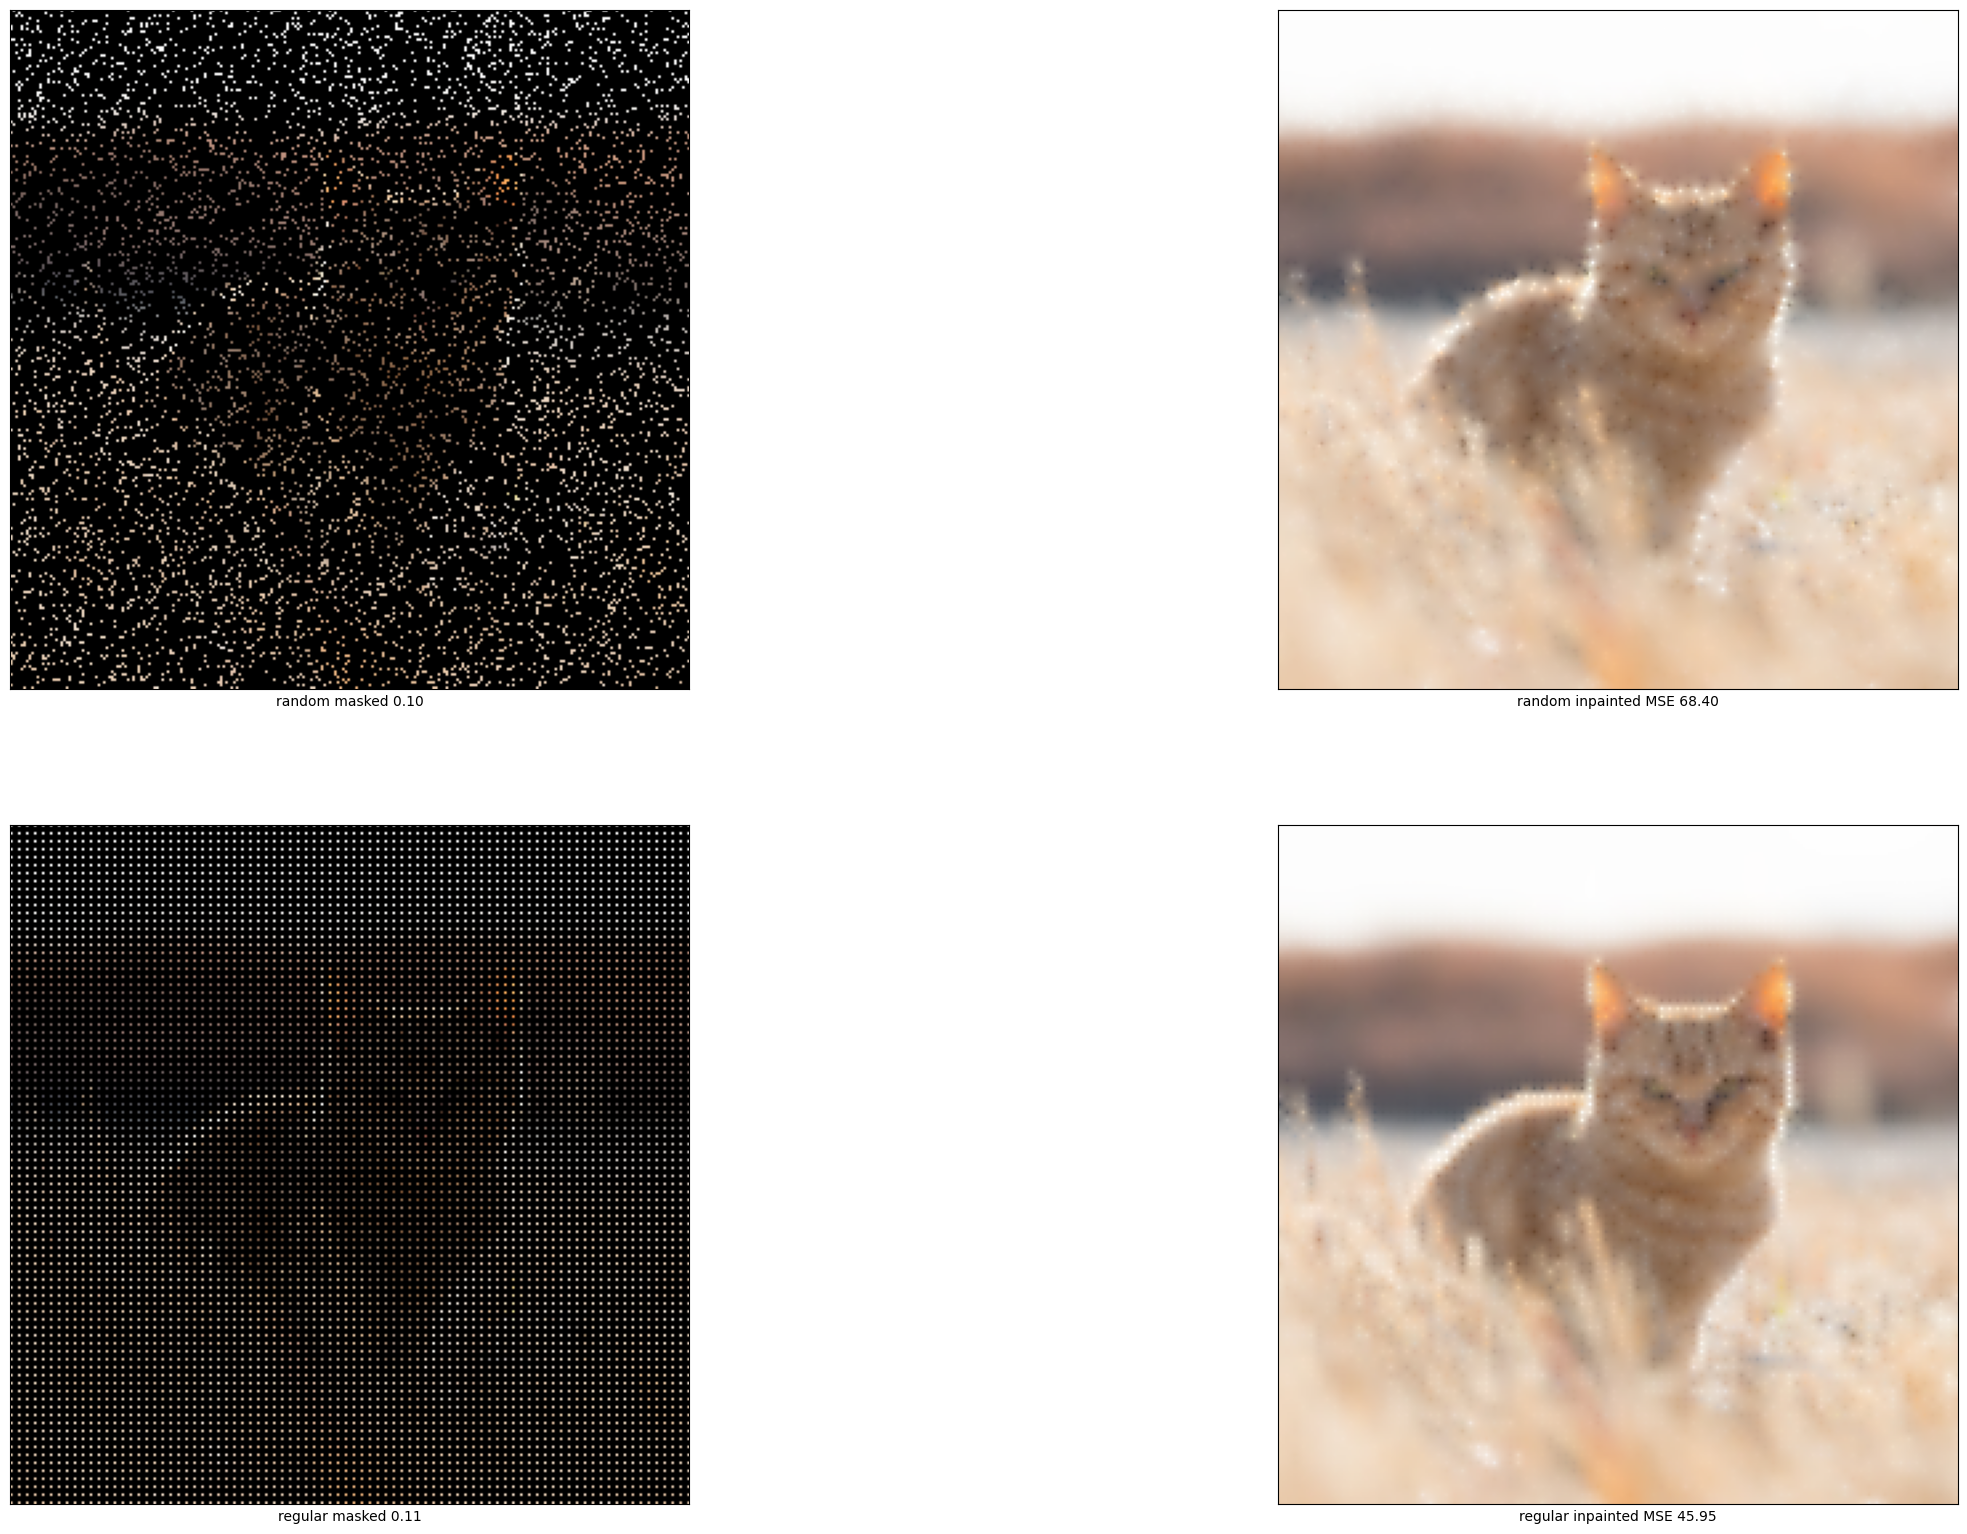

In [4]:
def inpaint_hom_diff(known_image_data, mask, num_iterations=500, tau=0.1):
    inpainted = known_image_data.copy()
    h = 1.0  # unit grid spacing

    # Initialize unknown pixels with average of known pixels (per channel)
    for c in range(3):  # R, G, B channels
        # ADD YOUR CODE HERE.
        known_values = known_image_data[:, :, c][mask]
        avg_value = np.mean(known_values)
        inpainted[:, :, c][~mask] = avg_value

    inpainted = inpainted.astype(float)
    
    # Inpaint.
    update_mask = ~mask
    for _ in range(num_iterations):
        # ADD YOUR CODE HERE.
        # Hints: 
        # You can do this without any additional for loops if you want better efficiency!
        # You may use np.pad to handle the boundaries.
        
        padded = np.pad(inpainted, ((1, 1), (1, 1), (0, 0)), mode='edge')

        # Compute Laplacian for all channels
        laplacian = (
            padded[2:, 1:-1, :] +   # down
            padded[0:-2, 1:-1, :] + # up
            padded[1:-1, 2:, :] +   # right
            padded[1:-1, 0:-2, :] - # left
            4 * padded[1:-1, 1:-1, :]
        ) / h

        # Update only unknown pixels
        inpainted[update_mask] += tau * laplacian[update_mask]

    return inpainted.astype(int)

iterations = 150 # ADD YOUR CODE HERE.
tau = 0.25
random_inpainted = inpaint_hom_diff(original_image, random_mask, iterations, tau)
mse_random = np.mean((original_image - random_inpainted) ** 2)
regular_inpainted = inpaint_hom_diff(original_image, regular_mask, iterations, tau)
mse_regular = np.mean((original_image - regular_inpainted) ** 2)
display_images([(random_masked, f'random masked {random_density:.2f}' ),
                (random_inpainted, f'random inpainted MSE {mse_random:.2f}' ),
                (regular_masked, f"regular masked {regular_density:.2f}"),
                (regular_inpainted, f"regular inpainted MSE {mse_regular:.2f}")], rows=3, figsize=(30,30))


### P6.2 Probabilistic Sparsification and NLPE (12=6+6P)
In the cells below, fill in the missing code for the following routines:
- <code>probabilistic_sparsification</code> (6P): Complete the function such that it performs the probabilistic sparsification algorithm with the homogeneous diffusion from the previous cell.
- <code>nonlocal_pixel_exchange</code> (6P):  Complete the method for NLPE with homogeneous diffusion.

Hint: If sparsification and NLPE are slow on your system, you can first test them with a lower amount of diffusion iterations. Potential bugfixing should be much more convenient that way. Of course, the number of diffusion iterations also has a significant impact on the runtime.

Note: NLPE iterations are fixed to 100 here. If you want to see the its true potential, you can crank it up multiple orders of magnitudes and you will notice the error is still decreasing. It takes a *long* time to converge. These are small changes, but they add up over time and you would get a significant improvement. Try it for yourself if you have enough patience. This is more fun with a more efficient implementation of diffusion inpainting, though. ;-)

Sparsification: 59009px [01:36, 608.56px/s, MSE=17.59]                 
NLPE: 100%|██████████| 100/100 [00:49<00:00,  2.02it/s, best=15.56, changes=61]


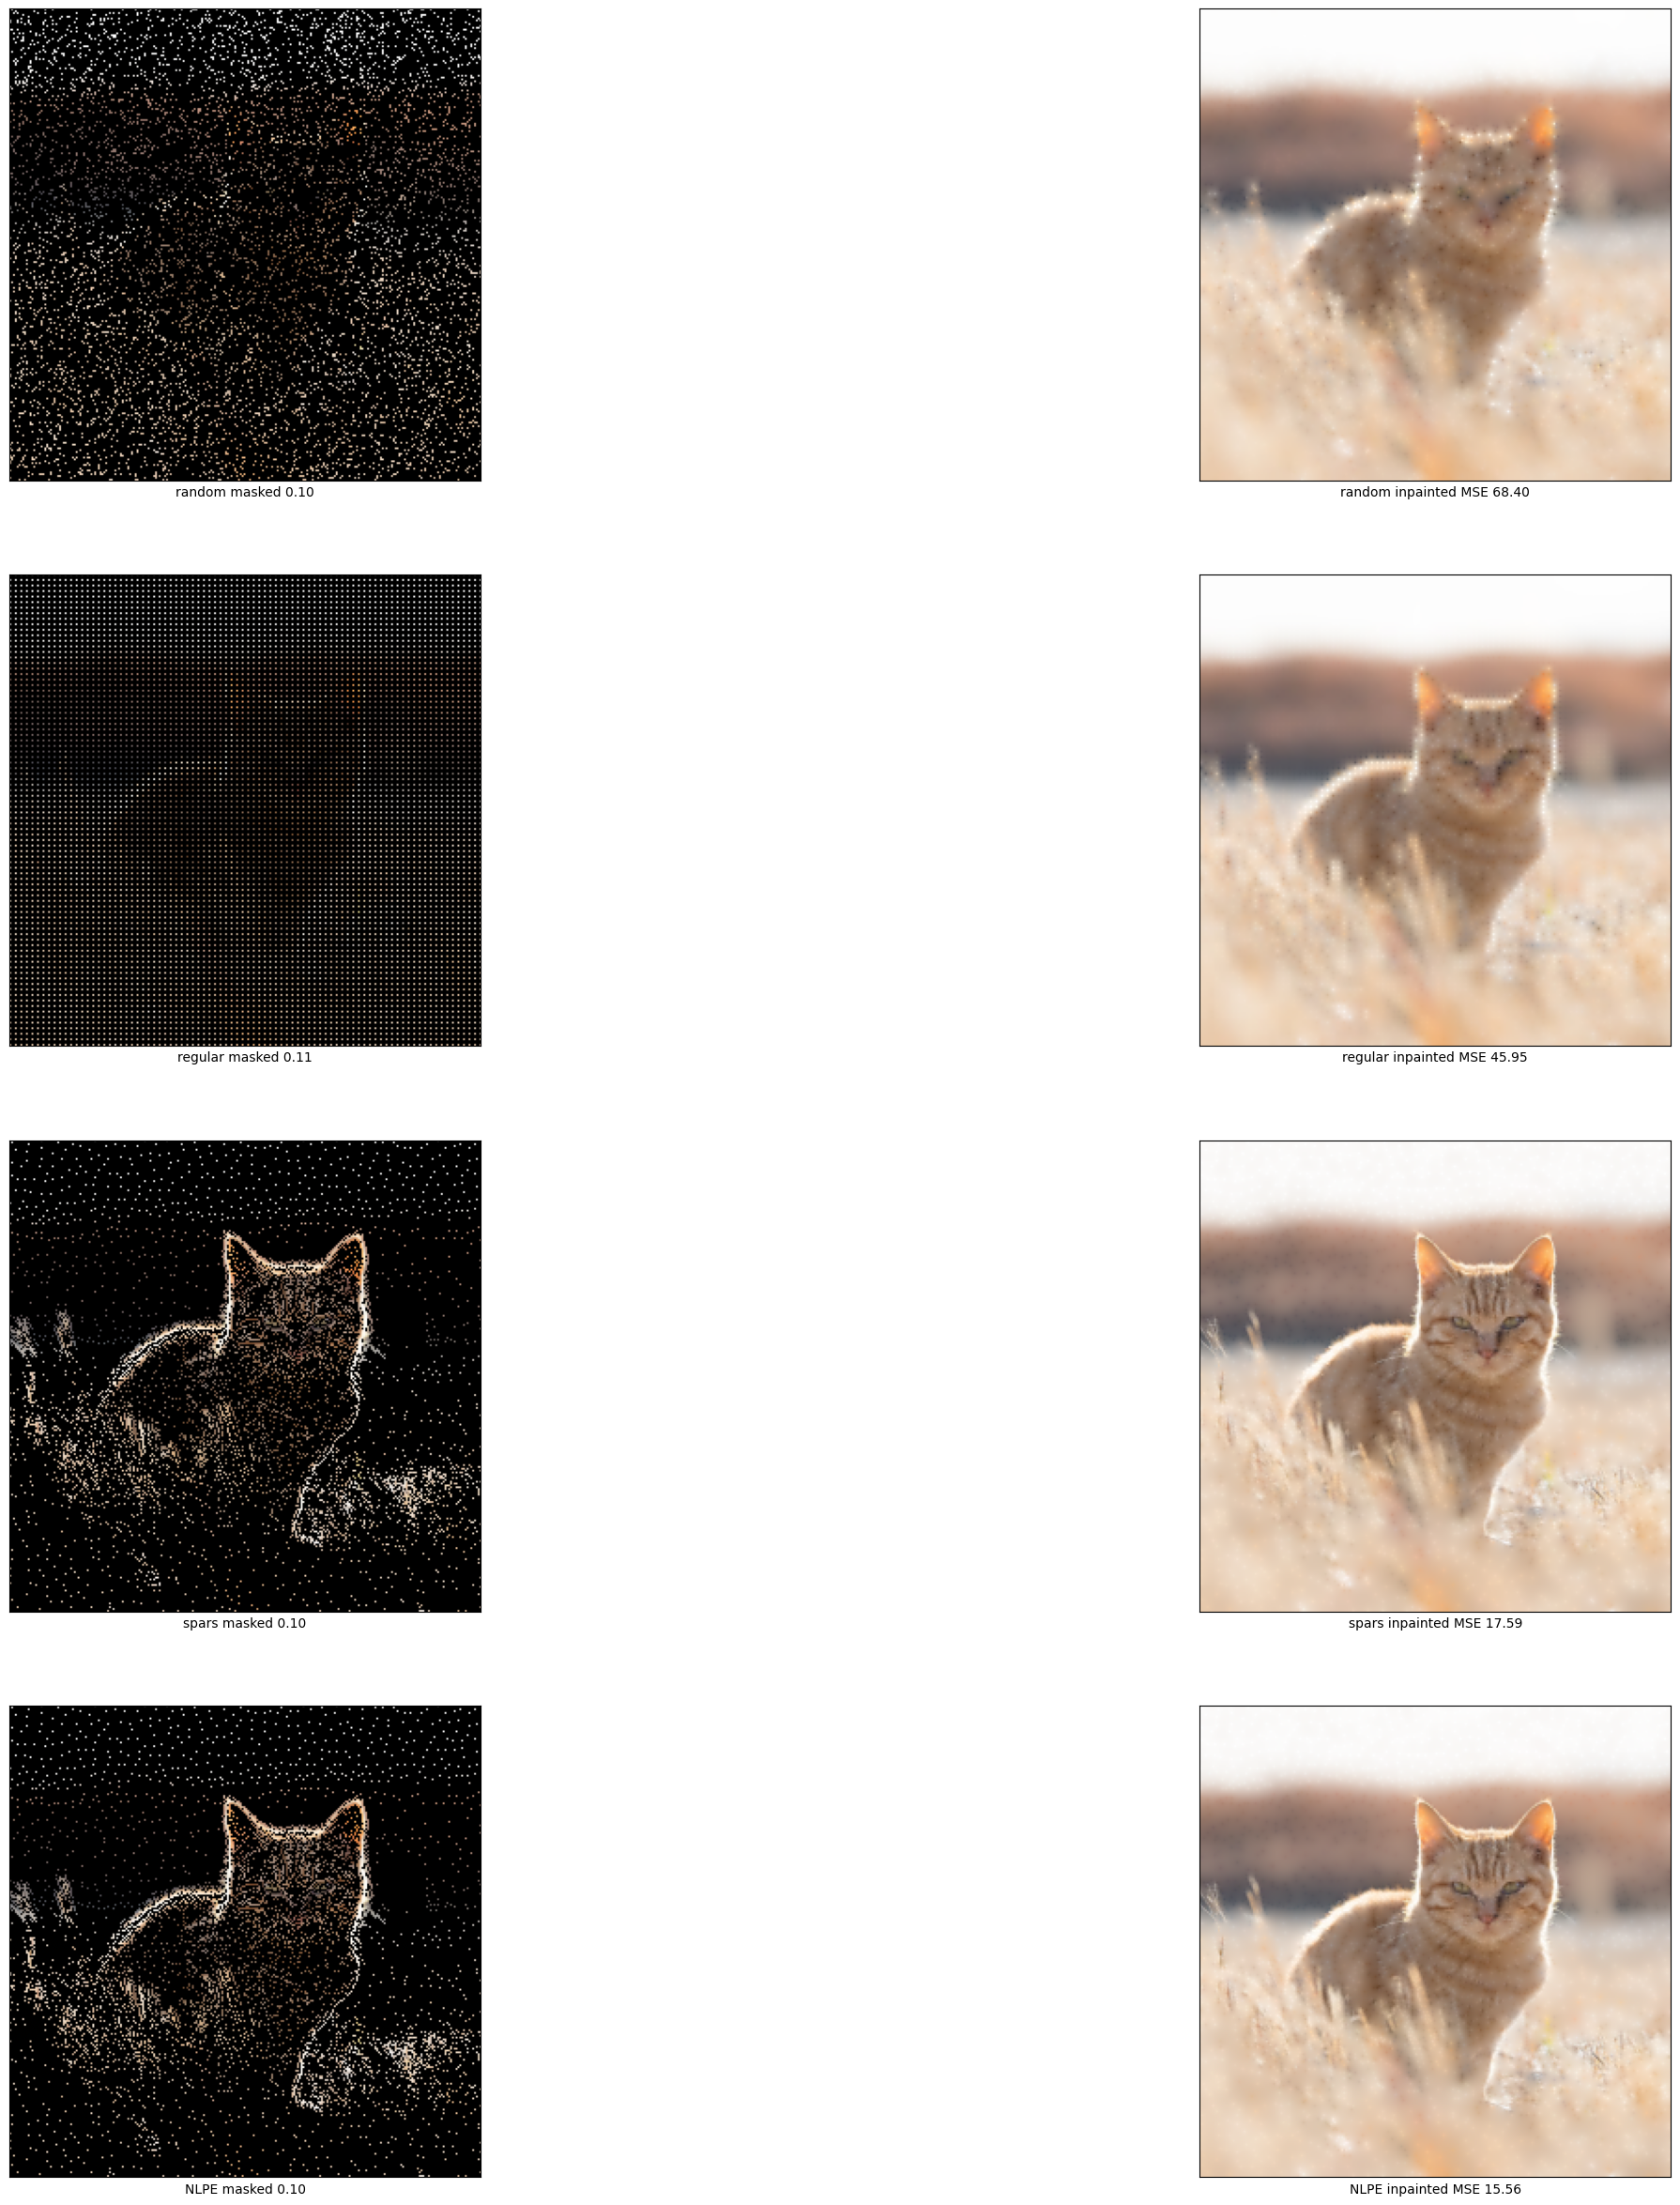

In [5]:
def probabilistic_sparsification(image, initial_mask, density, tau=0.25, diff_iterations=500, p=0.1, q=0.1):
    mask = initial_mask.copy()
    H, W, _ = image.shape
    total_pixels = H * W
    target_known = int(density * total_pixels)
    inpainted = inpaint_hom_diff(image, mask, tau=tau, num_iterations=diff_iterations)
    known = set(zip(*np.where(mask)))

    with tqdm(total=np.sum(mask) - target_known, desc="Sparsification", unit="px") as pbar:
        while np.sum(mask) > target_known:

            # ADD YOUR CODE HERE.
            candidate_pool = np.array(list(known))
            if len(candidate_pool) == 0:
                break
            candidates = candidate_pool[np.random.choice(len(candidate_pool), 
                                        size=max(1, int(p * len(known))), replace=False)]

            temp_mask = mask.copy()
            temp_mask[candidates[:, 0], candidates[:, 1]] = False
            
            inpainted_new = inpaint_hom_diff(image, temp_mask, tau=tau, num_iterations=diff_iterations)
            errors = np.mean((inpainted_new[candidates[:, 0], candidates[:, 1], :] - image[candidates[:, 0], candidates[:, 1], :])**2, axis=1)

            keep_indices = np.argsort(errors)[-int((1 - q) * len(candidates)):]
            for i, j in candidates[keep_indices]:
                temp_mask[i, j] = True

            removed = np.sum(mask) - np.sum(temp_mask)
            pbar.update(removed)

            mask = temp_mask
            inpainted = inpainted_new
            known = set(zip(*np.where(mask)))

        inpainted_new = inpaint_hom_diff(image, mask, tau=tau, num_iterations=diff_iterations)
        mse = np.mean((inpainted_new  - image)**2)
        pbar.set_postfix(MSE=f"{mse:.2f}")

    return mask


def nonlocal_pixel_exchange(image, mask, nlpe_iterations=100, tau=0.25, diff_iterations=500, n_candidates=10):
    
    # Initial inpainting
    inpainted = inpaint_hom_diff(image, mask, tau=tau, num_iterations=diff_iterations)
    mask = mask.copy()
    K = set(zip(*np.where(mask)))  # known pixels

    mse_old = np.mean((inpainted - image) ** 2)
    changes = 0

    with tqdm(total=nlpe_iterations, desc="NLPE", unit="it") as pbar:
        for _ in range(nlpe_iterations):

            # ADD YOUR CODE HERE.
            
            unknown_coords = list(zip(*np.where(~mask)))
            if len(unknown_coords) == 0 or len(K) == 0:
                break

            # choose n unknown pixels as candidate set I
            n = min(n_candidates, len(unknown_coords))
            candidates = np.array(unknown_coords)[np.random.choice(len(unknown_coords), size=n, replace=False)]

            # compute local errors
            local_errors = np.array([
                np.mean((inpainted[i, j] - image[i, j]) ** 2)
                for i, j in candidates
            ])

            # select random known j as the known pixel to be swapped
            known_j = list(K)[np.random.randint(len(K))]
            best_candidate = np.argmax(local_errors)
            unknown_i = tuple(candidates[best_candidate])

            # Step 4: Create new mask with swap
            mask[known_j] = False
            mask[unknown_i] = True

            # Step 5: Inpaint and evaluate
            inpainted_new = inpaint_hom_diff(image, mask, tau=tau, num_iterations=diff_iterations)
            mse_new = np.mean((inpainted_new - image) ** 2)

            if mse_new < mse_old:
                # Accept exchange
                inpainted = inpainted_new
                mse_old = mse_new
                K.remove(known_j)
                K.add(unknown_i)
                changes += 1
                pbar.set_postfix(best=f"{mse_new:.2f}", changes=f"{changes}")
            else:
                # Revert exchange
                mask[known_j] = True
                mask[unknown_i] = False

            pbar.update(1)

    return mask


diffusion_iterations = 150 # ADD YOUR CODE HERE
nlpe_iterations = 100
density = 0.1

initial_mask = np.ones(shape, dtype=bool)
spars_mask = probabilistic_sparsification(original_image, initial_mask, density, tau=tau, diff_iterations = diffusion_iterations)
nlpe_mask = nonlocal_pixel_exchange(original_image, spars_mask, nlpe_iterations, tau=tau, diff_iterations = diffusion_iterations)

spars_masked = original_image.copy()
spars_masked[~spars_mask] = 0
spars_inpainted = inpaint_hom_diff(original_image, spars_mask, diffusion_iterations, tau)
mse_spars = np.mean((original_image - spars_inpainted) ** 2)

nlpe_masked = original_image.copy()
nlpe_masked[~nlpe_mask] = 0
nlpe_inpainted = inpaint_hom_diff(original_image, nlpe_mask, diffusion_iterations, tau)
mse_nlpe = np.mean((original_image - nlpe_inpainted) ** 2)

display_images([(random_masked, f'random masked {random_density:.2f}' ),
                (random_inpainted, f'random inpainted MSE {mse_random:.2f}' ),
                (regular_masked, f"regular masked {regular_density:.2f}"),
                (regular_inpainted, f"regular inpainted MSE {mse_regular:.2f}"),
                (spars_masked, f"spars masked {density:.2f}"),
                (spars_inpainted, f"spars inpainted MSE {mse_spars:.2f}"),
                (nlpe_masked, f"NLPE masked {density:.2f}"),
                (nlpe_inpainted, f"NLPE inpainted MSE {mse_nlpe:.2f}")], rows=4, figsize=(30,30))

## Submission
Submit your jupyter notebook via CMS before the deadline.

In [6]:
import cv2

print(cv2.__version__)
print(hasattr(cv2, "xphoto"))

if hasattr(cv2, "xphoto"):
    print(hasattr(cv2.xphoto, "INPAINT_SHIFTMAP"))

4.13.0
True
True


In [7]:
import cv2

print("OpenCV:", cv2.__version__)
print("xphoto:", hasattr(cv2, "xphoto"))

print("Telea:", hasattr(cv2, "INPAINT_TELEA"))
print("Navier-Stokes:", hasattr(cv2, "INPAINT_NS"))

if hasattr(cv2, "xphoto"):
    print(
        "ShiftMap:",
        hasattr(cv2.xphoto, "INPAINT_SHIFTMAP")
    )

OpenCV: 4.13.0
xphoto: True
Telea: True
Navier-Stokes: True
ShiftMap: True
